<a href="https://colab.research.google.com/github/sayaka-sugiyama-jp/Adaptive-Frontline-Governance-Sustains-Rural-Infrastructure-Projects/blob/main/Frontline_governance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data and requirements

In [ ]:
%load_ext rpy2.ipython

In [ ]:
%%R
install.packages(c("dplyr","fixest","modelsummary","MatchIt","tidyr","cobalt"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘zoo’, ‘Formula’, ‘bayestestR’, ‘datawizard’, ‘numDeriv’, ‘sandwich’, ‘dreamerr’, ‘stringmagic’, ‘checkmate’, ‘insight’, ‘parameters’, ‘performance’, ‘tables’, ‘tinytable’, ‘chk’, ‘RcppProgress’, ‘gridExtra’

trying URL 'https://cran.rstudio.com/src/contrib/zoo_1.8-15.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/Formula_1.2-5.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/bayestestR_0.18.1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/datawizard_1.3.1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/numDeriv_2016.8-1.1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/sandwich_3.1-1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/dreamerr_1.5.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/stringmagic_1.2.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/checkmate_2.3.4.tar.gz'
trying URL 'https:

In [ ]:
!pip install rpy2
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
import pandas as pd
import numpy as np
from google.colab import files
from google.colab import drive
from cycler import cycler

drive.mount('/mnt/drive', force_remount=True)

Mounted at /mnt/drive


In [ ]:
import pandas as pd

save_dir = "/mnt/drive/MyDrive/Colab_data/"
DF = pd.read_csv(save_dir + "Matching_paddy/df.csv") #The original csv containing the data

# Histogram (downscale)

In [ ]:
import numpy as np

df_plot = DF.copy()

df_plot["TE"] = df_plot["TE"].replace([np.inf, -np.inf, 0], np.nan) #TE for Total expenditure/Estimate
df_plot = df_plot.dropna(subset=["TE"])

In [ ]:
df_plot.loc[df_plot["comp"] == 1, "TE"].describe()

,TE
count,508.000000
mean,0.732580
std,0.355656
min,0.017022
25%,0.582677
50%,0.791592
75%,0.902770
max,6.419591


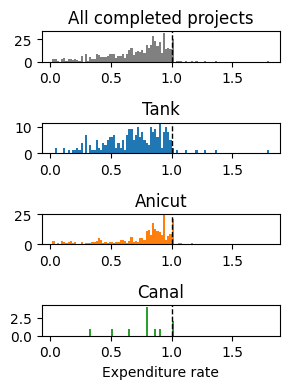

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# colormap
cmap = plt.get_cmap("tab10")

# cleaning
df_plot["type_tank_anicut_clean"] = ( #Types of infrastructure
    df_plot["type_tank_anicut"]
    .str.strip()
    .str.lower()
)

# Conditions
df_plot = df_plot[
    (df_plot["TE"] < 6) & #Removing one outlier
    (df_plot["comp"] == 1) # only completed projects
].copy()

# Groups
selected_groups = ["tank", "anicut", "canal"]

non_empty_groups = [
    g for g in selected_groups
    if not df_plot[
        df_plot["type_tank_anicut_clean"] == g
    ]["TE"].dropna().empty
]

data_min = df_plot["TE"].min()
data_max = df_plot["TE"].max()

bins = 100
bin_edges = np.linspace(data_min, data_max, bins + 1)

# figure
plt.figure(figsize=(3, 1 * (len(non_empty_groups) + 1)))

# -------------------
# All groups
# -------------------
plt.subplot(len(non_empty_groups) + 1, 1, 1)

plt.hist(
    df_plot["TE"].dropna(),
    bins=bin_edges,
    color="gray"
)

plt.title("All completed projects")
plt.ylabel("")

plt.axvline(
    1,
    color='black',
    linestyle='--',
    linewidth=1
)

# -------------------
# Each group
# -------------------
for i, g in enumerate(non_empty_groups):

    subset = df_plot[
        df_plot["type_tank_anicut_clean"] == g
    ]["TE"].dropna()

    plt.subplot(
        len(non_empty_groups) + 1,
        1,
        i + 2
    )

    plt.hist(
        subset,
        bins=bin_edges,
        color=cmap(i)
    )

    plt.title(g.capitalize())

    if i == len(non_empty_groups) - 1:
        plt.xlabel("Expenditure rate")

    plt.ylabel("")

    plt.axvline(
        1,
        color='black',
        linestyle='--',
        linewidth=1
    )

plt.tight_layout()

plt.savefig(
    "Downscale_treated_only.png",
    dpi=300
)

plt.show()

In [ ]:
from google.colab import files
files.download("Downscale_treated_only.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# DiD

## Running DiD

In [ ]:
%R -i DF

In [ ]:
%%R

library(dplyr)
library(fixest)
library(modelsummary)
library(MatchIt)
library(tidyr)
library(cobalt)

# ① 事前平均を計算（介入前のpaddy平均）
match_data <- DF %>%
  filter(
    ((comp==1 & ProjectCompletionYear == 2021 & TE>0 & TE<3) | (comp == 0))
  ) %>%
  drop_na(
    type_tank_anicut,
    population_sum_500,
    Imp,
    PROVINCE_C,
    Align,
    Align_LA
  )

# ② MatchIt
m.out <- matchit(
  comp ~ type_tank_anicut + population_sum_500 + Imp + PROVINCE_C + Align + Align_LA, data = match_data, method = "nearest", ratio = 1, caliper = 0.2, std.caliper = TRUE)

matched_df <- match.data(m.out)
matched_ids <- matched_df$project_id

# ③ Long
df_long <- df8 %>%
  pivot_longer(
    cols = starts_with("Paddy_"),
    names_to = c("area", "year"),
    names_pattern = "Paddy_(\\d+k)_(\\d+)",
    values_to = "paddy"
  ) %>%
  mutate(
    year = as.numeric(gsub("Paddy", "", year)),
    treat = ifelse(comp == 1,1,0),
    event_time = year - 2021,
    post = ifelse(year >= 2021, 1, 0)
  ) %>%
  filter(project_id %in% matched_ids)
df_long$paddy1000<-df_long$paddy/1000
df_long_1 <- filter(df_long, area =="1k")
df_long_2 <- filter(df_long, area =="2k")
df_long_3 <- filter(df_long, area =="3k")
df_long_4 <- filter(df_long, area =="4k")
df_long_5 <- filter(df_long, area =="5k")

# --- Event Study
es_model1 <- feols(paddy1000 ~ i(event_time, treat, ref = -1) | project_id + year, data = df_long_1, cluster = ~project_id)
es_model2 <- feols(paddy1000 ~ i(event_time, treat, ref = -1) | project_id + year, data = df_long_2, cluster = ~project_id)
es_model3 <- feols(paddy1000 ~ i(event_time, treat, ref = -1) | project_id + year, data = df_long_3, cluster = ~project_id)
es_model4 <- feols(paddy1000 ~ i(event_time, treat, ref = -1) | project_id + year, data = df_long_4, cluster = ~project_id)
es_model5 <- feols(paddy1000 ~ i(event_time, treat, ref = -1) | project_id + year, data = df_long_5, cluster = ~project_id)

The variables 'treat' and 'post' have been removed because of collinearity (see
$collin.var).
The variables 'treat' and 'post' have been removed because of collinearity (see
$collin.var).
The variables 'treat' and 'post' have been removed because of collinearity (see
$collin.var).
The variables 'treat' and 'post' have been removed because of collinearity (see
$collin.var).
The variables 'treat' and 'post' have been removed because of collinearity (see
$collin.var).


In [ ]:
%%R

# ① Avarage before the treatment
match_data <- df8 %>%
  mutate(trend_paddy_pre = Paddy2020-Paddy2017, na.rm = TRUE) %>%
  filter((comp==1&ProjectCompletionYear == 2021 & TE>0 & TE<3) | (comp == 0)) %>%
  drop_na(
    type_tank_anicut,
    population_sum_500,
    Imp,
    PROVINCE_C,
    Align,
    Align_LA
  )


# ② MatchIt
m.out <- matchit(comp ~ type_tank_anicut + population_sum_500 + Imp + PROVINCE_C + Align + Align_LA, data = match_data, method = "nearest", ratio = 1, caliper = 0.2, std.caliper = TRUE)

matched_df <- match.data(m.out)
matched_ids <- matched_df$project_id

# ③ Long data
df_long2 <- df8 %>%
  pivot_longer(
    cols = starts_with("Paddy_"),
    names_to = c("area", "year"),
    names_pattern = "Paddy_(\\d+k)_(\\d+)",
    values_to = "paddy"
  ) %>%
  mutate(
    year = as.numeric(gsub("Paddy", "", year)),
    treat = ifelse(comp == 1,1,0),
    event_time = year - 2021,
    post = ifelse(year >= 2021, 1, 0)
  ) %>%
  filter(project_id %in% matched_ids)
df_long2$paddy1000<-df_long2$paddy/1000
df_long2_1 <- filter(df_long2, area =="1k")
df_long2_2 <- filter(df_long2, area =="2k")
df_long2_3 <- filter(df_long2, area =="3k")
df_long2_4 <- filter(df_long2, area =="4k")
df_long2_5 <- filter(df_long2, area =="5k")

# --- Heterogeneous treatment Event Study2
es_het_model2_1 <- feols(paddy1000 ~ i(event_time, treat, ref = -1) * TE | project_id + year, data = df_long2_1, cluster = ~project_id)
es_het_model2_2 <- feols(paddy1000 ~ i(event_time, treat, ref = -1) * TE | project_id + year, data = df_long2_2, cluster = ~project_id)
es_het_model2_3 <- feols(paddy1000 ~ i(event_time, treat, ref = -1) * TE | project_id + year, data = df_long2_3, cluster = ~project_id)
es_het_model2_4 <- feols(paddy1000 ~ i(event_time, treat, ref = -1) * TE | project_id + year, data = df_long2_4, cluster = ~project_id)
es_het_model2_5 <- feols(paddy1000 ~ i(event_time, treat, ref = -1) * TE | project_id + year, data = df_long2_5, cluster = ~project_id)

NOTE: 176 observations removed because of NA and infinite values (RHS: 176).
The variables 'treat', 'post', 'TE' and 'treat:TE' have been removed because of
collinearity (see $collin.var).
NOTE: 176 observations removed because of NA and infinite values (RHS: 176).
The variables 'treat', 'post', 'TE' and 'treat:TE' have been removed because of
collinearity (see $collin.var).
NOTE: 176 observations removed because of NA and infinite values (RHS: 176).
The variables 'treat', 'post', 'TE' and 'treat:TE' have been removed because of
collinearity (see $collin.var).
NOTE: 176 observations removed because of NA and infinite values (RHS: 176).
The variables 'treat', 'post', 'TE' and 'treat:TE' have been removed because of
collinearity (see $collin.var).
NOTE: 176 observations removed because of NA and infinite values (RHS: 176).
The variables 'treat', 'post', 'TE' and 'treat:TE' have been removed because of
collinearity (see $collin.var).
NOTE: 176 observations removed because of NA and infini

## Matching quality

In [ ]:
%%R
install.packages("kableExtra")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependency ‘svglite’

trying URL 'https://cran.rstudio.com/src/contrib/svglite_2.2.2.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/kableExtra_1.4.0.tar.gz'

The downloaded source packages are in
	‘/tmp/Rtmpl7eTNk/downloaded_packages’


In [ ]:
%%R

library(dplyr)
library(MatchIt)
library(knitr)
library(kableExtra)

# =========================
# Variables used in matching
# =========================
vars <- c(
  "type_tank_anicut",
  "population_sum_500",
  "Imp",
  "PROVINCE_C",
  "Align",
  "Align_LA"
)

# =========================
# Function
# =========================
make_balance_row <- function(var, data_before, data_after){

  x_before <- data_before[[var]]
  x_after  <- data_after[[var]]

  # -------------------------
  # Numeric variable
  # -------------------------
  if(is.numeric(x_before)){

    p_before <- tryCatch(
      t.test(x_before ~ data_before$comp)$p.value,
      error = function(e) NA
    )

    p_after <- tryCatch(
      t.test(x_after ~ data_after$comp)$p.value,
      error = function(e) NA
    )

    out <- data.frame(
      Variable = var,

      N_Control_Before =
        sum(data_before$comp == 0 & !is.na(x_before)),

      N_Treated_Before =
        sum(data_before$comp == 1 & !is.na(x_before)),

      Mean_Control_Before =
        mean(x_before[data_before$comp == 0], na.rm = TRUE),

      Mean_Treated_Before =
        mean(x_before[data_before$comp == 1], na.rm = TRUE),

      Diff_Before =
        mean(x_before[data_before$comp == 1], na.rm = TRUE) -
        mean(x_before[data_before$comp == 0], na.rm = TRUE),

      P_Before = p_before,

      N_Control_After =
        sum(data_after$comp == 0 & !is.na(x_after)),

      N_Treated_After =
        sum(data_after$comp == 1 & !is.na(x_after)),

      Mean_Control_After =
        mean(x_after[data_after$comp == 0], na.rm = TRUE),

      Mean_Treated_After =
        mean(x_after[data_after$comp == 1], na.rm = TRUE),

      Diff_After =
        mean(x_after[data_after$comp == 1], na.rm = TRUE) -
        mean(x_after[data_after$comp == 0], na.rm = TRUE),

      P_After = p_after
    )

    return(out)

  }

  # -------------------------
  # Factor / character
  # -------------------------
  else {

    levels_all <- unique(as.character(x_before))

    out_all <- lapply(levels_all, function(lv){

      b_dummy <- ifelse(as.character(x_before) == lv, 1, 0)
      a_dummy <- ifelse(as.character(x_after)  == lv, 1, 0)

      p_before <- tryCatch(
        prop.test(table(data_before$comp, b_dummy))$p.value,
        error = function(e) NA
      )

      p_after <- tryCatch(
        prop.test(table(data_after$comp, a_dummy))$p.value,
        error = function(e) NA
      )

      data.frame(
        Variable = paste0(var, ": ", lv),

        N_Control_Before =
          sum(data_before$comp == 0),

        N_Treated_Before =
          sum(data_before$comp == 1),

        Mean_Control_Before =
          mean(b_dummy[data_before$comp == 0], na.rm = TRUE),

        Mean_Treated_Before =
          mean(b_dummy[data_before$comp == 1], na.rm = TRUE),

        Diff_Before =
          mean(b_dummy[data_before$comp == 1], na.rm = TRUE) -
          mean(b_dummy[data_before$comp == 0], na.rm = TRUE),

        P_Before = p_before,

        N_Control_After =
          sum(data_after$comp == 0),

        N_Treated_After =
          sum(data_after$comp == 1),

        Mean_Control_After =
          mean(a_dummy[data_after$comp == 0], na.rm = TRUE),

        Mean_Treated_After =
          mean(a_dummy[data_after$comp == 1], na.rm = TRUE),

        Diff_After =
          mean(a_dummy[data_after$comp == 1], na.rm = TRUE) -
          mean(a_dummy[data_after$comp == 0], na.rm = TRUE),

        P_After = p_after
      )

    })

    return(bind_rows(out_all))
  }
}

# =========================
# Create balance table
# =========================
balance_table <- lapply(
  vars,
  make_balance_row,
  data_before = match_data,
  data_after  = matched_df
) %>%
  bind_rows()

# =========================
# Round
# =========================
balance_table <- balance_table %>%
  mutate(across(where(is.numeric), ~ round(.x, 2)))

# =========================
# Latex table
# =========================
latex_tab <- kbl(
  balance_table,
  format = "latex",
  booktabs = TRUE,
  digits = 2,
  caption = "Covariate Balance Before and After Matching",
  align = "lcccccccccccc"
) %>%
  add_header_above(c(
    " " = 1,
    "Before Matching" = 6,
    "After Matching" = 6
  )) %>%
  kable_styling(
    latex_options = c("hold_position", "scale_down")
  )

latex_tab <- as.character(latex_tab)

latex_tab <- gsub(
  "(-?[0-9]+\\.[0-9]+)",
  "\\\\num{\\1}",
  latex_tab
)

writeLines(latex_tab, "balance_table.tex")

cat(latex_tab)

\begin{table}[!h]
\centering
\caption{Covariate Balance Before and After Matching}
\centering
\resizebox{\ifdim\width>\linewidth\linewidth\else\width\fi}{!}{
\begin{tabular}[t]{lcccccccccccc}
\toprule
\multicolumn{1}{c}{ } & \multicolumn{6}{c}{Before Matching} & \multicolumn{6}{c}{After Matching} \\
\cmidrule(l{3pt}r{3pt}){2-7} \cmidrule(l{3pt}r{3pt}){8-13}
Variable & N\_Control\_Before & N\_Treated\_Before & Mean\_Control\_Before & Mean\_Treated\_Before & Diff\_Before & P\_Before & N\_Control\_After & N\_Treated\_After & Mean\_Control\_After & Mean\_Treated\_After & Diff\_After & P\_After\\
\midrule
type\_tank\_anicut: anicut & 679 & 228 & \num{0.27} & \num{0.56} & \num{0.29} & \num{0.00} & 181 & 181 & \num{0.50} & \num{0.54} & \num{0.04} & \num{0.53}\\
type\_tank\_anicut: tank & 679 & 228 & \num{0.64} & \num{0.41} & \num{-0.23} & \num{0.00} & 181 & 181 & \num{0.49} & \num{0.44} & \num{-0.04} & \num{0.46}\\
type\_tank\_anicut: other & 679 & 228 & \num{0.00} & \num{0.01} & \num{0.01} &


Attaching package: ‘kableExtra’

The following object is masked from ‘package:dplyr’:

    group_rows

In addition: Warning messages:
1: In prop.test(table(data_before$comp, b_dummy)) :
  Chi-squared approximation may be incorrect
2: In prop.test(table(data_after$comp, a_dummy)) :
  Chi-squared approximation may be incorrect
3: In prop.test(table(data_before$comp, b_dummy)) :
  Chi-squared approximation may be incorrect
4: In prop.test(table(data_before$comp, b_dummy)) :
  Chi-squared approximation may be incorrect
5: In prop.test(table(data_before$comp, b_dummy)) :
  Chi-squared approximation may be incorrect
6: In prop.test(table(data_before$comp, b_dummy)) :
  Chi-squared approximation may be incorrect
7: In prop.test(table(data_before$comp, b_dummy)) :
  Chi-squared approximation may be incorrect
8: In prop.test(table(data_before$comp, b_dummy)) :
  Chi-squared approximation may be incorrect
9: In prop.test(table(data_before$comp, b_dummy)) :
  Chi-squared approximation may be inc

## Event study table

In [ ]:
%%R
tab <- etable(
  es_model1, es_model2, es_model3, es_model4, es_model5,

  tex = TRUE,
  digits = 2,

  dict = c(
    "event_time::-4:treat" = "t = -4",
    "event_time::-3:treat" = "t = -3",
    "event_time::-2:treat" = "t = -2",
    "event_time::0:treat"  = "t = 0",
    "event_time::1:treat"  = "t = +1",
    "event_time::2:treat"  = "t = +2",
    "event_time::3:treat"  = "t = +3"
  ),

  keep = "%event_time",

  se = "cluster",
  cluster = "project_id",

  signif.code = c(
    "***" = 0.001,
    "**"  = 0.01,
    "*"   = 0.05,
    "†"   = 0.1
  )
)

tab <- gsub(
  "(-?[0-9]+\\.[0-9]+)",
  "\\\\num{\\1}",
  tab
)

writeLines(tab, "event_study.tex")

cat(tab)

\begingroup \centering \begin{tabular}{lccccc}    \tabularnewline \midrule \midrule    Dependent Variable: & \multicolumn{5}{c}{paddy1000}\\    Model:       & (1)     & (2)       & (3)        & (4)       & (5)\\      \midrule    \emph{Variables}\\    t = -4       & \num{-0.30}   & \num{-0.25}     & \num{0.32}       & \num{1.9}       & \num{3.3}\\                    & (\num{0.30})  & (\num{0.92})    & (\num{1.7})      & (\num{2.8})     & (\num{4.2})\\       t = -3       & \num{-0.38}   & \num{-0.15}     & \num{-1.5}       & \num{-2.5}      & \num{-2.8}\\                    & (\num{0.28})  & (\num{0.85})    & (\num{1.6})      & (\num{2.6})     & (\num{3.7})\\       t = -2       & \num{-0.14}   & \num{-0.01}     & \num{-0.26}      & \num{-0.47}     & \num{0.12}\\                    & (\num{0.19})  & (\num{0.58})    & (\num{1.0})      & (\num{1.6})     & (\num{2.1})\\       t = 0        & \num{0.01}    & \num{0.58}      & \num{1.6}        & \num{2.0}       & \num{3.4}\\                    

In [ ]:
from google.colab import files
files.download('/content/event_study.tex')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Event study table (with heterogenous effect)

In [ ]:
%%R

tab <- etable(
  es_het_model2_1,
  es_het_model2_2,
  es_het_model2_3,
  es_het_model2_4,
  es_het_model2_5,

  tex = TRUE,
  digits = 2,

  dict = c(
    # Baseline effect
    "event_time::-4:treat" = "Baseline: t = -4",
    "event_time::-3:treat" = "Baseline: t = -3",
    "event_time::-2:treat" = "Baseline: t = -2",
    "event_time::0:treat"  = "Baseline: t = 0",
    "event_time::1:treat"  = "Baseline: t = +1",
    "event_time::2:treat"  = "Baseline: t = +2",
    "event_time::3:treat"  = "Baseline: t = +3",

    # Treatment effect heterogeneity
    "TE:event_time::-4:treat" = "TE × t = -4",
    "TE:event_time::-3:treat" = "TE × t = -3",
    "TE:event_time::-2:treat" = "TE × t = -2",
    "TE:event_time::0:treat"  = "TE × t = 0",
    "TE:event_time::1:treat"  = "TE × t = +1",
    "TE:event_time::2:treat"  = "TE × t = +2",
    "TE:event_time::3:treat"  = "TE × t = +3"
  ),

  keep = c("%event_time", "%TE:event_time"),

  se = "cluster",
  cluster = "project_id",

  signif.code = c(
    "***" = 0.001,
    "**"  = 0.01,
    "*"   = 0.05,
    "†"   = 0.1
  ),

  fixef_sizes = TRUE,

  notes = "t = -1 is the omitted reference period. Baseline effects correspond to the control group. TE denotes treatment-effect heterogeneity."
)

tab <- gsub(
  "(-?[0-9]+\\.[0-9]+)",
  "\\\\num{\\1}",
  tab
)

writeLines(tab, "event_study_heterogeneity.tex")

cat(tab)

\begingroup \centering \begin{tabular}{lccccc}    \tabularnewline \midrule \midrule    Dependent Variable: & \multicolumn{5}{c}{paddy1000}\\    Model:             & (1)     & (2)     & (3)        & (4)          & (5)\\      \midrule    \emph{Variables}\\    Baseline: t = -4   & \num{-0.81}   & \num{-0.58}   & \num{-0.59}      & \num{-0.72}        & \num{-4.6}\\                          & (\num{0.70})  & (\num{2.0})   & (\num{4.3})      & (\num{7.2})        & (\num{11.4})\\       Baseline: t = -3   & \num{-0.74}   & \num{-1.2}    & \num{-3.0}       & \num{-4.8}         & \num{-8.6}\\                          & (\num{0.73})  & (\num{2.1})   & (\num{4.2})      & (\num{6.8})        & (\num{10.0})\\       Baseline: t = -2   & \num{-0.34}   & \num{-1.3}    & \num{-1.2}       & \num{-0.40}        & \num{-0.67}\\                          & (\num{0.43})  & (\num{1.4})   & (\num{2.5})      & (\num{3.5})        & (\num{4.6})\\       Baseline: t = 0    & \num{0.26}    & \num{1.7}     & \num{5.2}$^

In [ ]:
from google.colab import files
files.download('/content/event_study_heterogeneity.tex')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Event study plot

In [ ]:
%R -o es_df

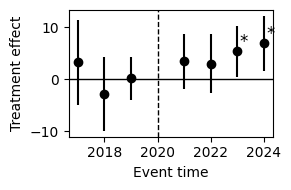

In [ ]:
import matplotlib.pyplot as plt

# event_time
es_df["event_time"] = es_df["term"].str.extract(r'(-?\d+)').astype(int)

# Sort
es_df = es_df.sort_values("event_time")

def add_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    elif p < 0.1:
        return "†"
    else:
        return ""

import matplotlib.pyplot as plt

es_df["stars"] = es_df["p.value"].apply(add_stars)

plt.figure(figsize=(3,2))

plt.errorbar(
    es_df["event_time"] + 2021,
    es_df["estimate"],
    yerr=1.96 * es_df["std.error"],
    fmt='o',
    color = 'black'
)

for _, row in es_df.iterrows():
    plt.text(
        row["event_time"] + 2021 + 0.1,
        row["estimate"] + 0.02,
        row["stars"],
        ha='left',
        va='bottom',
        size = 12
    )

plt.axhline(0, color='black', linewidth=1)
plt.axvline(2020, color='black', linestyle='--', linewidth=1)

plt.xlabel("Event time")
plt.ylabel("Treatment effect")
plt.title("")

plt.tight_layout()
plt.savefig("Completion_impact.png", dpi=300)
plt.show()

In [ ]:
from google.colab import files
files.download("Completion_impact.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Event study plot (with heterogenous effect)

In [ ]:
%R -o es_te

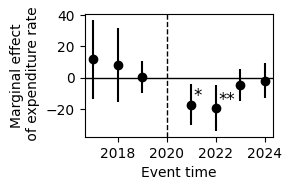

In [ ]:
import matplotlib.pyplot as plt

# event_time
es_te["event_time"] = es_te["term"].str.extract(r'event_time::(-?\d+)').astype(int)

# Sort
es_te = es_te.sort_values("event_time")

def add_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    elif p < 0.1:
        return "†"
    else:
        return ""

es_te["stars"] = es_te["p.value"].apply(add_stars)

# Plot
plt.figure(figsize=(3,2))

plt.errorbar(
    es_te["event_time"]+ 2021,
    es_te["estimate"],
    yerr=1.96 * es_te["std.error"],
    fmt='o',
    color = 'black'
)

# Stars
for _, row in es_te.iterrows():
    plt.text(
        row["event_time"] + 2021 + 0.1,
        row["estimate"] + 0.02,
        row["stars"],
        ha='left',
        va='bottom',
        size=12
    )

plt.axhline(0, color='black', linewidth=1)
plt.axvline(2020, color='black', linestyle='--', linewidth=1)

plt.xlabel("Event time")
plt.ylabel("Marginal effect\n of expenditure rate")
plt.title("")

plt.tight_layout()
plt.savefig("Downscale_impact.png", dpi=300)
plt.show()

In [ ]:
from google.colab import files
files.download("Downscale_impact.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Descriptive statistics

In [ ]:
%%R

library(dplyr)
library(knitr)

# =========================
# Variables used in matching
# =========================
desc_data <- match_data %>%
  select(
    comp,
    type_tank_anicut,
    population_sum_500,
    Imp,
    PROVINCE_C,
    Align,
    Align_LA
  )

# =========================
# Convert factor variables to dummies
# =========================
desc_data <- model.matrix(
  ~ . - 1,
  data = desc_data
) %>%
  as.data.frame()

# =========================
# Clean Inf
# =========================
desc_data <- desc_data %>%
  mutate(
    across(
      where(is.numeric),
      ~ ifelse(is.infinite(.x), NA, .x)
    )
  )

# =========================
# Variable labels
# =========================
var_labels <- c(

  comp = "Treatment",

  population_sum_500 = "Population (500m)",

  Align = "Political alignment (central)",

  Align_LA = "Political alignment (local)"
)

# rename known vars
names(desc_data) <- ifelse(
  names(desc_data) %in% names(var_labels),
  var_labels[names(desc_data)],
  names(desc_data)
)

# =========================
# Descriptive statistics
# =========================
desc_table <- data.frame(
  Variable = names(desc_data),

  N = sapply(desc_data, function(x)
    sum(!is.na(x))),

  Mean = sapply(desc_data, function(x)
    mean(x, na.rm = TRUE)),

  SD = sapply(desc_data, function(x)
    sd(x, na.rm = TRUE)),

  Min = sapply(desc_data, function(x)
    min(x, na.rm = TRUE)),

  Median = sapply(desc_data, function(x)
    median(x, na.rm = TRUE)),

  Max = sapply(desc_data, function(x)
    max(x, na.rm = TRUE))
)

# =========================
# Remove NaN / Inf
# =========================
desc_table <- desc_table %>%
  mutate(across(
    where(is.numeric),
    ~ ifelse(is.nan(.) | is.infinite(.), NA, .)
  ))

# =========================
# Round
# =========================
desc_table <- desc_table %>%
  mutate(across(where(is.numeric), ~ round(.x, 2)))

# =========================
# Latex table
# =========================
tab <- kable(
  desc_table,
  format = "latex",
  booktabs = TRUE,
  align = "lcccccc",
  caption = "Descriptive Statistics of Matching Variables"
)

# =========================
# Add label only
# =========================
tab <- sub(
  "\\\\begin\\{table\\}",
  "\\\\begin{table}[htbp]\n\\\\label{tab:matching_desc_stats}",
  tab
)

# =========================
# Add \num{}
# =========================
tab <- gsub(
  "(-?[0-9]+\\.[0-9]+)",
  "\\\\num{\\1}",
  tab
)

# =========================
# Remove NA strings
# =========================
tab <- gsub("NA", "", tab)
tab <- gsub("NaN", "", tab)
tab <- gsub("Inf", "", tab)

# =========================
# Save
# =========================
writeLines(tab, "matching_descriptive_statistics.tex")

cat(tab)

\begin{table}[htbp]
\label{tab:matching_desc_stats}

\caption{Descriptive Statistics of Matching Variables}
\centering
\begin{tabular}[t]{llcccccc}
\toprule
  & Variable & N & Mean & SD & Min & Median & Max\\
\midrule
Treatment & Treatment & 907 & \num{0.25} & \num{0.43} & 0 & 0 & \num{1.00}\\
type\_tank\_anicutanicut & type\_tank\_anicutanicut & 907 & \num{0.34} & \num{0.47} & 0 & 0 & \num{1.00}\\
type\_tank\_anicutcanal & type\_tank\_anicutcanal & 907 & \num{0.06} & \num{0.24} & 0 & 0 & \num{1.00}\\
type\_tank\_anicutculvert & type\_tank\_anicutculvert & 907 & \num{0.00} & \num{0.03} & 0 & 0 & \num{1.00}\\
type\_tank\_anicutother & type\_tank\_anicutother & 907 & \num{0.00} & \num{0.06} & 0 & 0 & \num{1.00}\\
\addlinespace
type\_tank\_anicutroad & type\_tank\_anicutroad & 907 & \num{0.00} & \num{0.07} & 0 & 0 & \num{1.00}\\
type\_tank\_anicutstream & type\_tank\_anicutstream & 907 & \num{0.00} & \num{0.03} & 0 & 0 & \num{1.00}\\
type\_tank\_anicutswebund & type\_tank\_anicutswebund &

In [ ]:
summary_stats = []

# All groups
all_te = df_plot["TE"].dropna()

summary_stats.append({
    "Group": "All",
    "N": len(all_te),
    "Mean": all_te.mean(),
    "SD": all_te.std()
})

# Group
for g in non_empty_groups:

    subset = df_plot[
        df_plot["type_tank_anicut_clean"] == g
    ]["TE"].dropna()

    summary_stats.append({
        "Group": g,
        "N": len(subset),
        "Mean": subset.mean(),
        "SD": subset.std()
    })

# DataFrame
summary_df = pd.DataFrame(summary_stats)

summary_df = summary_df.round({
    "Mean": 2,
    "SD": 2
})

print(summary_df)

    Group    N  Mean    SD
0     All  507  0.72  0.25
1    tank  237  0.69  0.25
2  anicut  253  0.75  0.25
3   canal   11  0.76  0.20
